# 02 — Multitask Fine-tuning **mBERT** (Vietnamese)

Pipeline giống notebook 01 để so sánh công bằng, chỉ đổi backbone sang:
- `bert-base-multilingual-cased`

> Khuyến nghị: `DO_SEGMENTATION = False`

In [33]:
#%pip install -U torch transformers datasets accelerate evaluate scikit-learn pandas numpy matplotlib seaborn underthesea joblib

In [34]:
import os

# Root dự án (đảm bảo bạn đang chạy notebook trong ./notebooks/)
# Nếu bạn chạy ở chỗ khác, hãy chỉnh PROJECT_ROOT cho đúng.
PROJECT_ROOT = os.path.abspath("..")

PATHS = {
    "train_csv": os.path.join(PROJECT_ROOT, "datasets", "processed", "train.csv"),
    "val_csv":   os.path.join(PROJECT_ROOT, "datasets", "processed", "validation.csv"),
    "test_csv":  os.path.join(PROJECT_ROOT, "datasets", "processed", "test.csv"),
    "metrics":   os.path.join(PROJECT_ROOT, "outputs", "metrics"),
    "figures":   os.path.join(PROJECT_ROOT, "outputs", "figures"),
    "preds":     os.path.join(PROJECT_ROOT, "outputs", "output_data"),
}

for k in ["metrics","figures","preds"]:
    os.makedirs(PATHS[k], exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("Train CSV =", PATHS["train_csv"])

PROJECT_ROOT = c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST
Train CSV = c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\datasets\processed\train.csv


## 1) Seed & Device

In [35]:
import random, numpy as np, torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

## 2) Load CSV

In [36]:
import pandas as pd

train_df = pd.read_csv(PATHS["train_csv"])
val_df   = pd.read_csv(PATHS["val_csv"])
test_df  = pd.read_csv(PATHS["test_csv"])

required_cols = ["sentence", "sentiment_id", "topic_id"]
for name, df in [("train",train_df),("val",val_df),("test",test_df)]:
    for c in required_cols:
        assert c in df.columns, f"[{name}] thiếu cột: {c}"
    df["sentence"] = df["sentence"].astype(str)

train_df = train_df[required_cols].copy()
val_df   = val_df[required_cols].copy()
test_df  = test_df[required_cols].copy()

print("Shapes:", train_df.shape, val_df.shape, test_df.shape)
train_df.head()

Shapes: (11426, 3) (1583, 3) (3166, 3)


,sentence,sentiment_id,topic_id
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0


## 3) Label maps

In [37]:
SENT_ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}
LABEL2SENT_ID = {v:k for k,v in SENT_ID2LABEL.items()}

TOPIC_ID2LABEL = {0:"lecturer", 1:"training_program", 2:"facility", 3:"others"}
LABEL2TOPIC_ID = {v:k for k,v in TOPIC_ID2LABEL.items()}

NUM_SENT = len(SENT_ID2LABEL)
NUM_TOPICS = len(TOPIC_ID2LABEL)

SENT_ID2LABEL, TOPIC_ID2LABEL

({0: 'negative', 1: 'neutral', 2: 'positive'},
 {0: 'lecturer', 1: 'training_program', 2: 'facility', 3: 'others'})

## 4) EDA ngắn

Sentiment distribution (train):


sentiment_id
0    5325
1     458
2    5643
Name: count, dtype: int64

sentiment_id
0    0.466042
1    0.040084
2    0.493874
Name: proportion, dtype: float64

Topic distribution (train):


topic_id
0    8166
1    2201
2     497
3     562
Name: count, dtype: int64

topic_id
0    0.714686
1    0.192631
2    0.043497
3    0.049186
Name: proportion, dtype: float64

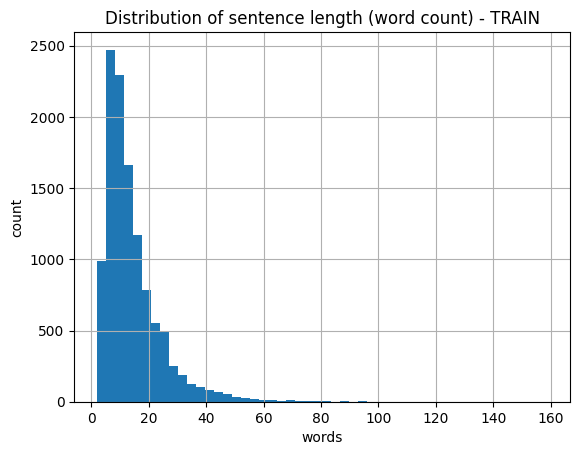

count    11426.000000
mean        14.308769
std         10.089727
min          2.000000
25%          8.000000
50%         11.000000
75%         17.000000
max        159.000000
Name: len_words, dtype: float64

In [38]:
import matplotlib.pyplot as plt

print("Sentiment distribution (train):")
display(train_df["sentiment_id"].value_counts().sort_index())
display(train_df["sentiment_id"].value_counts(normalize=True).sort_index())

print("Topic distribution (train):")
display(train_df["topic_id"].value_counts().sort_index())
display(train_df["topic_id"].value_counts(normalize=True).sort_index())

tmp = train_df.copy()
tmp["len_words"] = tmp["sentence"].astype(str).apply(lambda x: len(x.split()))
plt.figure()
tmp["len_words"].hist(bins=50)
plt.title("Distribution of sentence length (word count) - TRAIN")
plt.xlabel("words"); plt.ylabel("count")
plt.show()

tmp["len_words"].describe()

## 5) Preprocess

In [39]:
import re

def remove_html(text: str) -> str:
    return re.sub(r"<.*?>", " ", text)

def remove_url(text: str) -> str:
    return re.sub(r"http\S+|www\S+", " ", text)

def normalize_spaces(text: str) -> str:
    return " ".join(str(text).split())

_EMOJI = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\u2600-\u26FF"
    "\u2700-\u27BF"
    "]+",
    flags=re.UNICODE
)

def remove_emoji(text: str) -> str:
    return _EMOJI.sub(" ", text)

ABBR = {
    "ko":"không","k":"không","kh":"không","hok":"không","k0":"không",
    "bt":"bình thường","ok":"ổn","dc":"được","đc":"được","vs":"với",
    "th":"thầy","gv":"giảng viên","sv":"sinh viên"
}
def expand_abbr(text: str) -> str:
    tokens = str(text).split()
    tokens = [ABBR.get(t.lower(), t) for t in tokens]
    return " ".join(tokens)

USE_WORD_SEGMENT = False
try:
    from underthesea import word_tokenize
    USE_WORD_SEGMENT = True
except Exception:
    USE_WORD_SEGMENT = False

def preprocess_vi(text: str, do_segment: bool = False) -> str:
    text = str(text)
    text = remove_html(text)
    text = remove_url(text)
    text = remove_emoji(text)
    text = expand_abbr(text)
    text = normalize_spaces(text)
    if do_segment and USE_WORD_SEGMENT:
        text = word_tokenize(text, format="text")
    return text

DO_SEGMENTATION = False  # mBERT: giữ False để fair comparison

for df in [train_df, val_df, test_df]:
    df["text"] = df["sentence"].apply(lambda x: preprocess_vi(x, do_segment=DO_SEGMENTATION))

train_df[["sentence","text"]].head(5)

,sentence,text
0,slide giáo trình đầy đủ .,slide giáo trình đầy đủ .
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .","nhiệt tình giảng dạy , gần gũi với sinh viên ."
2,đi học đầy đủ full điểm chuyên cần .,đi học đầy đủ full điểm chuyên cần .
3,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp dụng công nghệ thông tin và các thiết ...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...","thầy giảng bài hay , có nhiều bài tập ví dụ ng..."


## 6) One-hot topic

In [40]:
import numpy as np

def to_onehot_topic(topic_id, num_topics=NUM_TOPICS):
    vec = np.zeros(num_topics, dtype=np.float32)
    vec[int(topic_id)] = 1.0
    return vec

train_df["topic_vec"] = train_df["topic_id"].apply(to_onehot_topic)
val_df["topic_vec"]   = val_df["topic_id"].apply(to_onehot_topic)
test_df["topic_vec"]  = test_df["topic_id"].apply(to_onehot_topic)

train_df[["topic_id","topic_vec"]].head()

,topic_id,topic_vec
0,1,"[0.0, 1.0, 0.0, 0.0]"
1,0,"[1.0, 0.0, 0.0, 0.0]"
2,1,"[0.0, 1.0, 0.0, 0.0]"
3,0,"[1.0, 0.0, 0.0, 0.0]"
4,0,"[1.0, 0.0, 0.0, 0.0]"


## 7) HF Dataset

In [41]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df[["text","sentiment_id","topic_vec"]])
val_ds   = Dataset.from_pandas(val_df[["text","sentiment_id","topic_vec"]])
test_ds  = Dataset.from_pandas(test_df[["text","sentiment_id","topic_vec"]])

train_ds, val_ds, test_ds

(Dataset({
     features: ['text', 'sentiment_id', 'topic_vec'],
     num_rows: 11426
 }),
 Dataset({
     features: ['text', 'sentiment_id', 'topic_vec'],
     num_rows: 1583
 }),
 Dataset({
     features: ['text', 'sentiment_id', 'topic_vec'],
     num_rows: 3166
 }))

## 8) Tokenizer (mBERT)

In [42]:
from transformers import AutoTokenizer, DataCollatorWithPadding

MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

train_ds_tok = train_ds.map(tok, batched=True)
val_ds_tok   = val_ds.map(tok, batched=True)
test_ds_tok  = test_ds.map(tok, batched=True)

collator = DataCollatorWithPadding(tokenizer=tokenizer)

c:\Users\ASUS\anaconda3\envs\ml\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(




Map: 100%|██████████| 11426/11426 [00:00<00:00, 23661.73 examples/s]

Map: 100%|██████████| 1583/1583 [00:00<00:00, 36272.16 examples/s]

Map: 100%|██████████| 3166/3166 [00:00<00:00, 35993.83 examples/s]


## 9) Model + Trainer

In [43]:
import torch
import torch.nn as nn
from transformers import AutoModel

class MultiTaskModel(nn.Module):
    """Shared encoder + 2 heads (sentiment softmax, topic sigmoid)."""
    def __init__(self, encoder_name: str, n_sent: int, n_topic: int, dropout=0.1, alpha=1.0):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden = self.encoder.config.hidden_size
        self.drop = nn.Dropout(dropout)

        self.sent_head = nn.Linear(hidden, n_sent)
        self.topic_head = nn.Linear(hidden, n_topic)

        self.ce = nn.CrossEntropyLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.alpha = float(alpha)

    def forward(
        self,
        input_ids=None,
        attention_mask=None,

        # ✅ nhận TÊN MÀ DATASET + TRAINER DÙNG
        sentiment_id=None,
        topic_vec=None,

        # (optional – để backward compatibility)
        sentiment_labels=None,
        topic_labels=None,
    ):
        # alias
        if sentiment_labels is None:
            sentiment_labels = sentiment_id
        if topic_labels is None:
            topic_labels = topic_vec

        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.drop(out.last_hidden_state[:, 0])

        sent_logits = self.sent_head(cls)
        topic_logits = self.topic_head(cls)

        loss = None
        if sentiment_labels is not None and topic_labels is not None:
            loss_sent = self.ce(sent_logits, sentiment_labels)
            loss_topic = self.bce(topic_logits, topic_labels)
            loss = loss_sent + self.alpha * loss_topic

        return {
            "loss": loss,
            "sent_logits": sent_logits,
            "topic_logits": topic_logits,
        }


In [44]:
from transformers import Trainer

class MultiTaskTrainer(Trainer):
    # Thêm **kwargs vào định nghĩa hàm để nhận các tham số lạ như num_items_in_batch
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        sentiment_labels = inputs.pop("sentiment_id")
        topic_labels = inputs.pop("topic_vec")
        outputs = model(**inputs, sentiment_labels=sentiment_labels, topic_labels=topic_labels)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

## 10) Format torch

In [45]:
def format_torch(ds):
    keep = ["input_ids","attention_mask","sentiment_id","topic_vec"]
    drop = [c for c in ds.column_names if c not in keep]
    ds = ds.remove_columns(drop)
    ds.set_format(type="torch")
    return ds

In [46]:
train_ds2 = format_torch(train_ds_tok)
val_ds2   = format_torch(val_ds_tok)
test_ds2  = format_torch(test_ds_tok)

## 11) Train

In [47]:
import os
from transformers import TrainingArguments

OUT_DIR = os.path.join(PROJECT_ROOT, "outputs", "models", "mbert_multitask")
os.makedirs(OUT_DIR, exist_ok=True)

ALPHA = 1.0

args = TrainingArguments(
    output_dir=OUT_DIR,

    evaluation_strategy="epoch",
    save_strategy="epoch",

    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,

    weight_decay=0.01,
    warmup_ratio=0.05,

    # ❌ BỎ các dòng gây lỗi
    load_best_model_at_end=False,
    # metric_for_best_model="eval_loss",

    logging_strategy="epoch",

    fp16=torch.cuda.is_available(),
    report_to="none",

    remove_unused_columns=False
)

model = MultiTaskModel(
    MODEL_NAME,
    n_sent=NUM_SENT,
    n_topic=NUM_TOPICS,
    alpha=ALPHA
).to(DEVICE)

trainer = MultiTaskTrainer(
    model=model,
    args=args,
    train_dataset=train_ds2,
    eval_dataset=val_ds2,
    tokenizer=tokenizer,
    data_collator=collator
)

trainer.train()


 20%|██        | 715/3575 [1:28:14<5:52:56,  7.40s/it]
                                                    
 20%|██        | 715/3575 [1:19:14<1:44:01,  2.18s/it]

{'loss': 0.6535, 'grad_norm': 10.877177238464355, 'learning_rate': 8.421672555948175e-06, 'epoch': 1.0}






















































                                                      
                                                 
 20%|██        | 715/3575 [1:20:25<1:44:01,  2.18s/it]


{'eval_runtime': 70.9939, 'eval_samples_per_second': 22.298, 'eval_steps_per_second': 0.704, 'epoch': 1.0}


                                                      
 20%|██        | 715/3575 [1:56:47<1:44:01,  2.18s/it] 

...





















































                                                      
                                                  
 20%|██        | 715/3575 [3:47:13<1:44:01,  2.18s/it]


{'eval_runtime': 69.2383, 'eval_samples_per_second': 22.863, 'eval_steps_per_second': 0.722, 'epoch': 5.0}


                                                      
100%|██████████| 3575/3575 [3:05:21<00:00,  3.11s/it]]

{'train_runtime': 11121.9485, 'train_samples_per_second': 5.137, 'train_steps_per_second': 0.321, 'train_loss': 0.35993692037942526, 'epoch': 5.0}


TrainOutput(global_step=3575, training_loss=0.35993692037942526, metrics={'train_runtime': 11121.9485, 'train_samples_per_second': 5.137, 'train_steps_per_second': 0.321, 'train_loss': 0.35993692037942526, 'epoch': 5.0})

## 12) Evaluate TEST

In [48]:
import numpy as np, torch
from transformers import DataCollatorWithPadding

def predict_logits(model, ds, tokenizer, batch_size=32, device="cpu"):
    model.eval()
    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=collator)

    sent_logits_all, topic_logits_all = [], []
    y_sent_all, y_topic_all = [], []

    for batch in loader:
        y_sent = batch.pop("sentiment_id")
        y_topic = batch.pop("topic_vec")

        batch = {k:v.to(device) for k,v in batch.items()}
        with torch.no_grad():
            out = model(**batch)
        sent_logits_all.append(out["sent_logits"].detach().cpu().numpy())
        topic_logits_all.append(out["topic_logits"].detach().cpu().numpy())
        y_sent_all.append(y_sent.detach().cpu().numpy())
        y_topic_all.append(y_topic.detach().cpu().numpy())

    return (
        np.vstack(sent_logits_all),
        np.vstack(topic_logits_all),
        np.concatenate(y_sent_all),
        np.vstack(y_topic_all),
    )

In [52]:
import numpy as np

def apply_threshold(prob, th=0.5, fallback="max"):
    """
    prob: np.ndarray, shape (N, C)
    th: threshold
    fallback:
        - "max": nếu không nhãn nào >= th → chọn nhãn có xác suất cao nhất
        - None: cho phép vector toàn 0
    """
    pred = (prob >= th).astype(int)

    if fallback == "max":
        for i in range(len(pred)):
            if pred[i].sum() == 0:
                pred[i, prob[i].argmax()] = 1

    return pred


In [53]:
sent_logits, topic_logits, y_sent_true, y_topic_true = predict_logits(
    model, test_ds2, tokenizer, batch_size=32, device=DEVICE
)

# Sentiment
y_sent_pred = sent_logits.argmax(-1)

# Topic (multi-label)
topic_prob = 1 / (1 + np.exp(-topic_logits))

DEFAULT_TH = 0.35
y_topic_pred = apply_threshold(topic_prob, th=DEFAULT_TH, fallback="max")


In [54]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np, os

def eval_sentiment(y_true, y_pred, out_prefix: str, figures_dir: str):
    acc = accuracy_score(y_true, y_pred)
    _, _, f1_ma, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    _, _, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    print("=== SENTIMENT METRICS ===")
    print({"accuracy": acc, "f1_macro": f1_ma, "f1_weighted": f1_w, "kappa": kappa, "mcc": mcc})
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=[SENT_ID2LABEL[i] for i in range(NUM_SENT)], digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=[SENT_ID2LABEL[i] for i in range(NUM_SENT)],
                yticklabels=[SENT_ID2LABEL[i] for i in range(NUM_SENT)])
    plt.title(f"{out_prefix} - Sentiment Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    fig_path = os.path.join(figures_dir, f"{out_prefix}_sent_cm.png")
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    return {"accuracy": float(acc), "f1_macro": float(f1_ma), "f1_weighted": float(f1_w), "kappa": float(kappa), "mcc": float(mcc), "cm_path": fig_path}

=== SENTIMENT METRICS ===
{'accuracy': 0.9226152874289324, 'f1_macro': 0.7926872583951191, 'f1_weighted': 0.9175730699747658, 'kappa': 0.8561334818360801, 'mcc': 0.8570195233401148}

Classification report:
              precision    recall  f1-score   support

    negative     0.9186    0.9610    0.9393      1409
     neutral     0.6842    0.3892    0.4962       167
    positive     0.9405    0.9447    0.9426      1590

    accuracy                         0.9226      3166
   macro avg     0.8478    0.7649    0.7927      3166
weighted avg     0.9172    0.9226    0.9176      3166



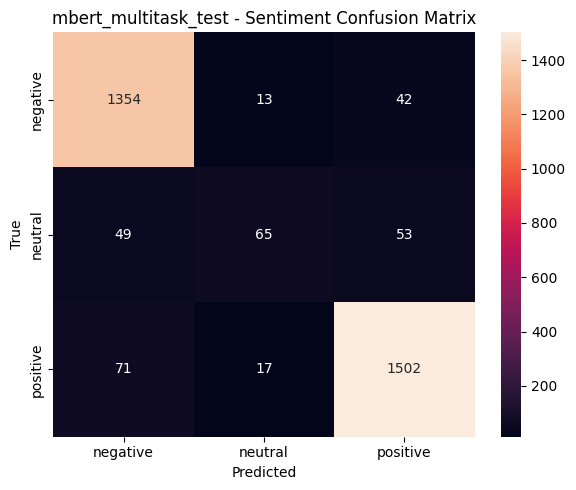

In [55]:
sent_metrics = eval_sentiment(y_sent_true, y_sent_pred, out_prefix="mbert_multitask_test", figures_dir=PATHS["figures"])

In [56]:
from sklearn.metrics import f1_score, hamming_loss, jaccard_score, classification_report, ConfusionMatrixDisplay
import numpy as np, os, matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def apply_threshold(prob, th=0.35, per_label_th=None, fallback="max"):
    if per_label_th is None:
        pred = (prob >= th).astype(int)
    else:
        per = np.asarray(per_label_th).reshape(1, -1)
        pred = (prob >= per).astype(int)

    if fallback == "max":
        for i in range(len(pred)):
            if pred[i].sum() == 0:
                pred[i, int(prob[i].argmax())] = 1
    return pred

def eval_topics(y_true, y_pred, out_prefix: str, figures_dir: str):
    f1_micro  = f1_score(y_true, y_pred, average="micro", zero_division=0)
    f1_macro  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_samples = f1_score(y_true, y_pred, average="samples", zero_division=0)
    ham = hamming_loss(y_true, y_pred)
    jac = jaccard_score(y_true, y_pred, average="samples", zero_division=0)

    print("=== TOPIC MULTI-LABEL METRICS ===")
    print({"f1_micro": f1_micro, "f1_macro": f1_macro, "f1_samples": f1_samples, "hamming": ham, "jaccard_samples": jac})

    topic_names = [TOPIC_ID2LABEL[i] for i in range(NUM_TOPICS)]
    print("\nPer-label report:")
    print(classification_report(y_true, y_pred, target_names=topic_names, digits=4, zero_division=0))

    for j, name in enumerate(topic_names):
        y_t = y_true[:, j]
        y_p = y_pred[:, j]
        ConfusionMatrixDisplay.from_predictions(y_t, y_p, labels=[0,1], cmap="Blues")
        plt.title(f"{out_prefix} - OvR Confusion (topic={name})")
        plt.tight_layout()
        fig_path = os.path.join(figures_dir, f"{out_prefix}_topic_{name}_ovr_cm.png")
        plt.savefig(fig_path, dpi=200, bbox_inches="tight")
        plt.show()

    return {"f1_micro": float(f1_micro), "f1_macro": float(f1_macro), "f1_samples": float(f1_samples), "hamming": float(ham), "jaccard_samples": float(jac)}

=== TOPIC MULTI-LABEL METRICS ===
{'f1_micro': 0.8852662630026393, 'f1_macro': 0.7703256332381153, 'f1_samples': 0.8895556959359866, 'hamming': 0.058354390397978524, 'jaccard_samples': 0.8840808591282375}

Per-label report:
                  precision    recall  f1-score   support

        lecturer     0.9285    0.9533    0.9407      2290
training_program     0.7128    0.8199    0.7626       572
        facility     0.8882    0.9310    0.9091       145
          others     0.5614    0.4025    0.4689       159

       micro avg     0.8705    0.9005    0.8853      3166
       macro avg     0.7727    0.7767    0.7703      3166
    weighted avg     0.8693    0.9005    0.8834      3166
     samples avg     0.8841    0.9005    0.8896      3166



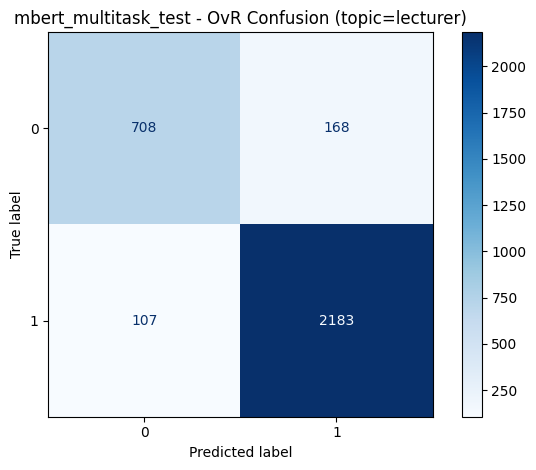

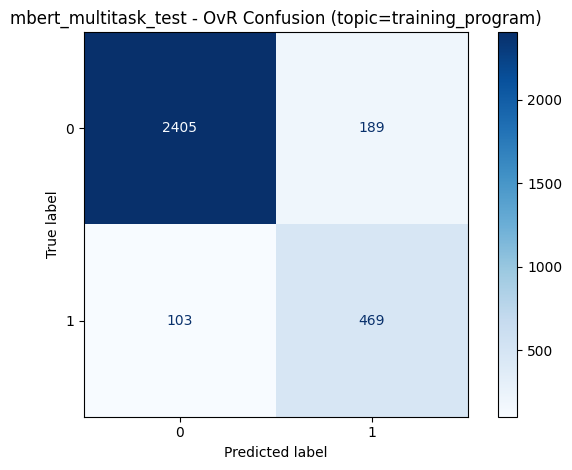

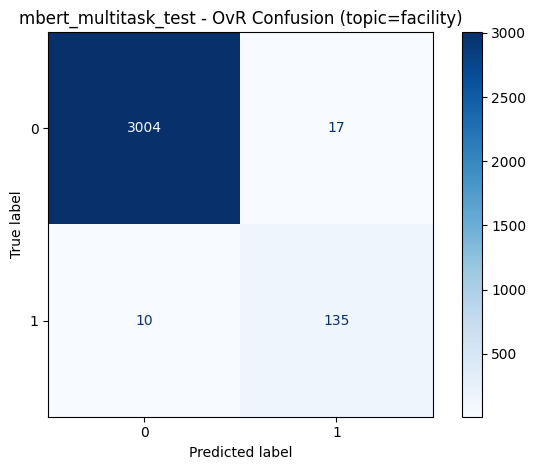

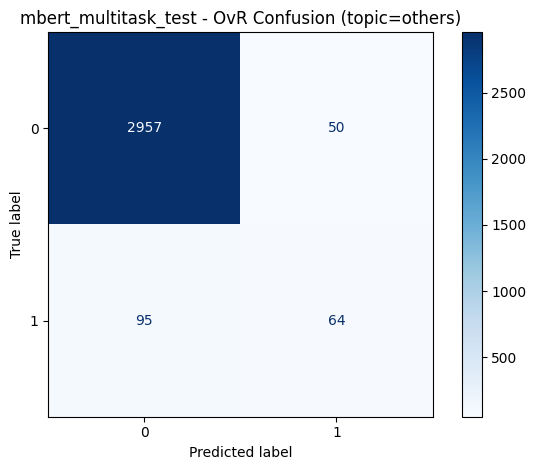

In [57]:
topic_metrics = eval_topics(y_topic_true, y_topic_pred, out_prefix="mbert_multitask_test", figures_dir=PATHS["figures"])

## 13) Save metrics & predictions

In [58]:
import json, pandas as pd, os

metrics = {"sentiment": sent_metrics, "topic": {"threshold": DEFAULT_TH, **topic_metrics}}
metrics_path = os.path.join(PATHS["metrics"], "mbert_multitask_test_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

pred_df = test_df.copy()
pred_df["sent_pred"] = y_sent_pred
pred_df["sent_pred_label"] = pred_df["sent_pred"].map(SENT_ID2LABEL)

for j in range(NUM_TOPICS):
    pred_df[f"topic_prob_{TOPIC_ID2LABEL[j]}"] = topic_prob[:, j]

pred_df.to_csv(os.path.join(PATHS["preds"], "mbert_multitask_test_predictions.csv"), index=False, encoding="utf-8-sig")
print("Saved:", metrics_path)

Saved: c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\outputs\metrics\mbert_multitask_test_metrics.json


## 14) Save model bundle

In [59]:
import os, json, torch

def save_bundle(save_dir, model, tokenizer, extra: dict):
    os.makedirs(save_dir, exist_ok=True)
    tokenizer.save_pretrained(save_dir)
    torch.save(model.state_dict(), os.path.join(save_dir, "pytorch_model.bin"))
    with open(os.path.join(save_dir, "label_maps.json"), "w", encoding="utf-8") as f:
        json.dump({"sentiment": SENT_ID2LABEL, "topic": TOPIC_ID2LABEL}, f, ensure_ascii=False, indent=2)
    with open(os.path.join(save_dir, "bundle_config.json"), "w", encoding="utf-8") as f:
        json.dump(extra, f, ensure_ascii=False, indent=2)
    print("Saved bundle to:", save_dir)

In [60]:
import datetime, os

SAVE_DIR = os.path.join(PROJECT_ROOT, "outputs", "models", "mbert_multitask", "final_model")
save_bundle(
    SAVE_DIR,
    model=model,
    tokenizer=tokenizer,
    extra={
        "encoder_name": MODEL_NAME,
        "alpha": ALPHA,
        "default_threshold": DEFAULT_TH,
        "max_length": 256,
        "do_segmentation": DO_SEGMENTATION,
        "created_at": str(datetime.datetime.now())
    }
)

Saved bundle to: c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\outputs\models\mbert_multitask\final_model


## 15) One-sample walkthrough

In [62]:
import torch, numpy as np

def walkthrough_one_sample(
    text: str,
    tokenizer,
    model,
    max_len=64,
    threshold=0.35,
    per_label_th=None
):
    print("=== 1) Raw text ===")
    print(text)

    print("\n=== 2) Preprocessed text ===")
    text2 = preprocess_vi(text, do_segment=DO_SEGMENTATION)
    print(text2)

    print("\n=== 3) Tokenize ===")
    enc = tokenizer(
        text2,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    print("Decoded tokens:", tokenizer.convert_ids_to_tokens(enc["input_ids"][0][:24]))

    print("\n=== 4) Model forward ===")
    model.eval()
    with torch.no_grad():
        out = model(
            input_ids=enc["input_ids"].to(DEVICE),
            attention_mask=enc["attention_mask"].to(DEVICE)
        )

    print("Output keys:", out.keys())

    # ===== Sentiment =====
    print("\n=== 5) Sentiment (softmax) ===")
    sent_logits = out["sent_logits"].detach().cpu().numpy()[0]
    sent_prob = np.exp(sent_logits) / np.exp(sent_logits).sum()
    sent_id = int(sent_prob.argmax())

    print("sent_prob =", np.round(sent_prob, 4))
    print("pred_sent =", SENT_ID2LABEL[sent_id])

    # ===== Topic =====
    print("\n=== 6) Topic (sigmoid + threshold) ===")
    topic_logits = out["topic_logits"].detach().cpu().numpy()[0]
    topic_prob = 1 / (1 + np.exp(-topic_logits))

    if per_label_th is None:
        y_pred = (topic_prob >= threshold).astype(int)
        th_used = [threshold] * len(topic_prob)
    else:
        th_used = per_label_th
        y_pred = (topic_prob >= np.array(per_label_th)).astype(int)

    # fallback: ít nhất 1 topic
    if y_pred.sum() == 0:
        y_pred[int(topic_prob.argmax())] = 1

    topics = [TOPIC_ID2LABEL[i] for i, v in enumerate(y_pred) if v == 1]

    print("topic_prob =", np.round(topic_prob, 4))
    print("thresholds =", np.round(th_used, 3))
    print("pred_topics =", topics)

    return {
        "sentiment": SENT_ID2LABEL[sent_id],
        "topics": topics,
        "topic_prob": topic_prob
    }


# ===== DEMO =====
demo_text = "Phòng học nóng quá, máy lạnh hư mà thầy giảng hơi nhanh."
_ = walkthrough_one_sample(
    demo_text,
    tokenizer,
    model,
    max_len=64,
    threshold=DEFAULT_TH
)


=== 1) Raw text ===
Phòng học nóng quá, máy lạnh hư mà thầy giảng hơi nhanh.

=== 2) Preprocessed text ===
Phòng học nóng quá, máy lạnh hư mà thầy giảng hơi nhanh.

=== 3) Tokenize ===
Decoded tokens: ['[CLS]', 'Phòng', 'học', 'nó', '##ng', 'quá', ',', 'máy', 'l', '##ạnh', 'h', '##ư', 'mà', 'th', '##ầy', 'giảng', 'hơi', 'nhanh', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

=== 4) Model forward ===
Output keys: dict_keys(['loss', 'sent_logits', 'topic_logits'])

=== 5) Sentiment (softmax) ===
sent_prob = [9.985e-01 7.000e-04 8.000e-04]
pred_sent = negative

=== 6) Topic (sigmoid + threshold) ===
topic_prob = [0.0447 0.0136 0.9648 0.0144]
thresholds = [0.35 0.35 0.35 0.35]
pred_topics = ['facility']


In [61]:
import torch, numpy as np

def walkthrough_one_sample(text: str, tokenizer, model, max_len=64, threshold=0.35, per_label_th=None):
    print("=== 1) Raw text ===")
    print(text)

    print("\n=== 2) Preprocessed text ===")
    text2 = preprocess_vi(text, do_segment=DO_SEGMENTATION)
    print(text2)

    print("\n=== 3) Tokenize (input_ids / attention_mask) ===")
    enc = tokenizer(text2, truncation=True, padding="max_length", max_length=max_len, return_tensors="pt")
    input_ids = enc["input_ids"][0].tolist()
    attn = enc["attention_mask"][0].tolist()
    print("input_ids[:32] =", input_ids[:32], "...")
    print("attention_mask[:32] =", attn[:32], "...")
    print("Decoded tokens[:24] =", tokenizer.convert_ids_to_tokens(input_ids[:24]))

    print("\n=== 4) Encoder output & CLS embedding ===")
    model.eval()
    with torch.no_grad():
        out = model(input_ids=enc["input_ids"].to(DEVICE), attention_mask=enc["attention_mask"].to(DEVICE))
    cls = out["cls"].detach().cpu()
    print("CLS shape =", tuple(cls.shape))
    print("CLS first 10 dims =", cls[0, :10].numpy())

    print("\n=== 5) Sentiment head (softmax) ===")
    sent_logits = out["sent_logits"].detach().cpu().numpy()[0]
    sent_prob = np.exp(sent_logits) / np.exp(sent_logits).sum()
    sent_id = int(sent_prob.argmax())
    print("sent_prob   =", np.round(sent_prob, 4))
    print("pred_sent   =", SENT_ID2LABEL[sent_id])

    print("\n=== 6) Topic head (sigmoid) + threshold ===")
    topic_logits = out["topic_logits"].detach().cpu().numpy()[0]
    topic_prob = 1 / (1 + np.exp(-topic_logits))
    if per_label_th is None:
        y_pred = (topic_prob >= threshold).astype(int)
        th_used = [threshold]*NUM_TOPICS
    else:
        th_used = list(per_label_th)
        y_pred = (topic_prob >= np.array(per_label_th)).astype(int)

    if y_pred.sum() == 0:
        y_pred[int(topic_prob.argmax())] = 1

    topics = [TOPIC_ID2LABEL[i] for i,v in enumerate(y_pred) if v==1]
    print("topic_prob   =", np.round(topic_prob, 4))
    print("thresholds   =", np.round(np.array(th_used), 3))
    print("pred_topics  =", topics)

    return {"sentiment": SENT_ID2LABEL[sent_id], "topics": topics, "topic_prob": topic_prob}

demo_text = "Phòng học nóng quá, máy lạnh hư mà thầy giảng hơi nhanh."
_ = walkthrough_one_sample(demo_text, tokenizer, model, max_len=64, threshold=DEFAULT_TH)

=== 1) Raw text ===
Phòng học nóng quá, máy lạnh hư mà thầy giảng hơi nhanh.

=== 2) Preprocessed text ===
Phòng học nóng quá, máy lạnh hư mà thầy giảng hơi nhanh.

=== 3) Tokenize (input_ids / attention_mask) ===
input_ids[:32] = [101, 82419, 11125, 14175, 10376, 27261, 117, 18838, 180, 55572, 176, 28776, 15542, 77586, 64761, 108697, 81379, 41652, 119, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...
attention_mask[:32] = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...
Decoded tokens[:24] = ['[CLS]', 'Phòng', 'học', 'nó', '##ng', 'quá', ',', 'máy', 'l', '##ạnh', 'h', '##ư', 'mà', 'th', '##ầy', 'giảng', 'hơi', 'nhanh', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

=== 4) Encoder output & CLS embedding ===


KeyError: 'cls'

## 16) Error analysis exporter

In [63]:
import numpy as np, pandas as pd, os

def build_error_tables(df_ref, y_sent_true, y_sent_pred, y_topic_true, topic_prob, y_topic_pred, out_prefix: str, preds_dir: str, top_k=30):
    out_dir = preds_dir
    os.makedirs(out_dir, exist_ok=True)

    sent_err_mask = (y_sent_true != y_sent_pred)
    sent_err = df_ref.loc[sent_err_mask, ["sentence","sentiment_id","topic_id"]].copy()
    sent_err["sent_true_label"] = pd.Series(y_sent_true[sent_err_mask]).map(SENT_ID2LABEL).values
    sent_err["sent_pred_label"] = pd.Series(y_sent_pred[sent_err_mask]).map(SENT_ID2LABEL).values
    sent_err_path = os.path.join(out_dir, f"{out_prefix}_error_sentiment.csv")
    sent_err.head(top_k).to_csv(sent_err_path, index=False, encoding="utf-8-sig")

    topic_err_mask = (y_topic_true != y_topic_pred).any(axis=1)
    topic_err = df_ref.loc[topic_err_mask, ["sentence","sentiment_id","topic_id"]].copy()

    def vec_to_labels(vec):
        idx = np.where(vec==1)[0].tolist()
        return [TOPIC_ID2LABEL[i] for i in idx]

    topic_err["topic_true_labels"] = [vec_to_labels(v) for v in y_topic_true[topic_err_mask]]
    topic_err["topic_pred_labels"] = [vec_to_labels(v) for v in y_topic_pred[topic_err_mask]]

    probs = topic_prob[topic_err_mask]
    for j in range(NUM_TOPICS):
        topic_err[f"prob_{TOPIC_ID2LABEL[j]}"] = probs[:, j]

    topic_err_path = os.path.join(out_dir, f"{out_prefix}_error_topic.csv")
    topic_err.head(top_k).to_csv(topic_err_path, index=False, encoding="utf-8-sig")

    print("Saved:", sent_err_path)
    print("Saved:", topic_err_path)
    return sent_err_path, topic_err_path

In [64]:
_ = build_error_tables(
    df_ref=test_df,
    y_sent_true=y_sent_true,
    y_sent_pred=y_sent_pred,
    y_topic_true=y_topic_true,
    topic_prob=topic_prob,
    y_topic_pred=y_topic_pred,
    out_prefix="mbert_multitask_test",
    preds_dir=PATHS["preds"],
    top_k=30
)

Saved: c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\outputs\output_data\mbert_multitask_test_error_sentiment.csv
Saved: c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\outputs\output_data\mbert_multitask_test_error_topic.csv
